## LLC Converter – Core Concepts (Technical Summary)

This section summarizes the essential physical and design principles required to correctly analyze, dimension, and interpret an LLC resonant converter, with focus on automotive on-board charger (OBC) applications.
Equations are taken from: https://www.infineon.com/assets/row/public/documents/24/42/infineon-design-example-resonant-llc-converter-operation-and-design-applicationnotes-en.pdf

---

### Resonant Tank
The resonant tank is the passive energy-shaping network located between the inverter bridge and the transformer primary.  
It consists of the elements that directly participate in resonance:

- **Lr (Resonant Inductance)**  
  Stores magnetic energy

- **Cr (Resonant Capacitance)**  
  Stores electric energy  


The resonant frequency is defined exclusively by Lr and Cr:

    fr = 1 / (2 · π · sqrt(Lr · Cr))

---

### Magnetizing Inductance (Lm)
- It represents the magnetizing inductance of the transformer
- Electrically connected in parallel to the power transfer path

Primary functions:
- Enables Zero Voltage Switching (ZVS) of the primary switches
- Defines no-load and light-load behavior
- Influences the gain curve near resonance

Design convention:

    Lm = k · Lr   with   k ≈ 5 … 8

---

### Resonant Tank Impedance (Zr)
The characteristic impedance of the resonant tank is defined as:

    Zr = sqrt(Lr / Cr)

Equivalent expressions commonly used in design:

    Zr = 2 · π · fr · Lr
    Zr = 1 / (2 · π · fr · Cr)

---

### Quality Factor (Q)
The quality factor describes how strongly the resonant tank is damped by the load:

    Q = Zr / Rload_ref

---

### Switching Bridge Gain 

    Fullbridge = 1 (useful if higher primary current)
    Half Bridge = 0.5 

---

### Tank Gain (G_tank)
The tank gain describes the AC voltage transfer of the resonant network only:

$$
K(Q,m,F_x)
=
\left|\frac{V_{o\_ac}(s)}{V_{in\_ac}(s)}\right|
=
\frac{F_x^{2}(m-1)}
{\sqrt{(mF_x^{2}-1)^{2}
+
F_x^{2}(F_x^{2}-1)^{2}(m-1)^{2}Q^{2}}}
$$

Where,

$$
Q=\frac{\sqrt{\dfrac{L_r}{C_r}}}{R_{ac}}
\qquad \text{Quality factor}
$$

$$
R_{ac}
=
\frac{8}{\pi^{2}}
\cdot
\frac{N_p^{2}}{N_s^{2}}
\cdot
R_o
\qquad \text{Reflected load resistance}
$$

$$
F_x=\frac{f_s}{f_r}
\qquad \text{Normalized switching frequency}
$$

$$
f_r=\frac{1}{2\pi\sqrt{L_r\,C_r}}
\qquad \text{Resonant frequency}
$$

$$
m=\frac{L_r+L_m}{L_r}
\qquad \text{Ratio of total primary inductance to resonant inductance}
$$






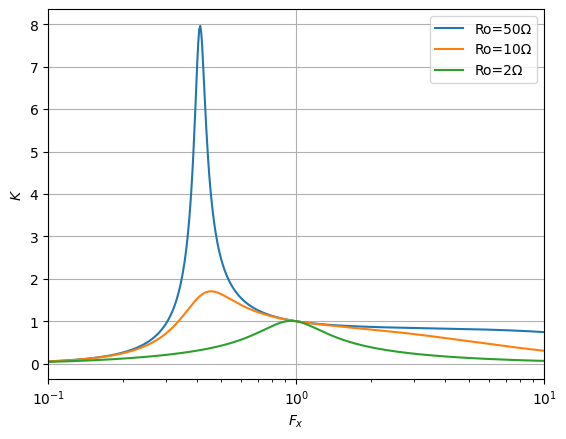

In [66]:
import numpy as np
import matplotlib.pyplot as plt

def resonant_tank_gain(Lr, Lm, Cr, Ro, Np, Ns, Fx):
    # aus Fx wird fs berechnet
    fr = 1/(2*np.pi*np.sqrt(Lr*Cr))
    fs = Fx * fr

    m  = (Lr + Lm)/Lr
    Rac = (8/np.pi**2) * (Np**2/Ns**2) * Ro
    Q = np.sqrt(Lr/Cr)/Rac

    K = (Fx**2*(m-1)) / np.sqrt((m*Fx**2 - 1)**2 +
                               Fx**2*(Fx**2 - 1)**2*(m-1)**2*Q**2)
    return K


# logarithmische Fx-Achse von 0.1 bis 10
Fx = np.logspace(-1, 1, 500)

# Beispielparameter
Lr = 10e-6
Lm = 50e-6      # -> m ≈ 6
Cr = 100e-9
Np = 10
Ns = 5

# verschiedene Lasten
Ros = [ 50, 10, 2]

for Ro in Ros:
    K = resonant_tank_gain(Lr, Lm, Cr, Ro, Np, Ns, Fx)
    plt.plot(Fx, K, label=f"Ro={Ro}Ω")

plt.xscale("log")
plt.xlim(0.1, 10)
plt.xlabel(r"$F_x$")
plt.ylabel(r"$K$")
plt.legend()
plt.grid(True)
plt.show()



### Regions
Left from peak is capacitive region, that should be avoided in operation to allow ZVS operation and avoid reverse current flow in FET body diodes
(current will start to lead the voltage). Preferred is operation in inductive region.

---

### flowchart

[START]
   |
   v
[Step 1: Select Qmax value]
   |
   v
[Step 2: Select m value]
   |
   v
[Step 3: Find Fx_min]
   |
   v
[Step 4: Find K_max]
   |
   v
{Is K_max = required gain?}
        |
   +----+----+
  Yes        No
   |          |
   v          v
[Step 5:   {Is K_max < required gain?}
 Solve for         |
 resonant      +---+---+
 components]  Yes     No
   |            |       |
   v            v       v
 [END]     [Increase] [Decrease]
            [m value]  [m value]
                 \       /
                  \     /
                   v   v
               [Step 3: Find Fx_min]

### Step 1 - Q value

High Q:
 -> larger Gain
 -> Gain less sensitive to frequency changes
    - switching frequency range may need to increase (losses up)

### Step 2 - m value

Low m value:
 -> Higher boost gain
 -> Narrower frequency range
 -> Moreflexible regulation

High m value:
 -> Higher magnetizing inductance
 -> Lower magnetizing circulating current
 -> Higher efficiency

 ### Step 3 - minimum normalized switching frequency

In [67]:
import numpy as np

# derived constant parameter
m = (Lr + Lm) / Lr

# Fx range (logarithmic, 0.1 … 10)
Fx = np.logspace(-1, 1, 5000)

for Ro in Ros:
    Rac = (8 / np.pi**2) * (Np**2 / Ns**2) * Ro
    Q = np.sqrt(Lr / Cr) / Rac

    K_vals = (Fx**2 * (m - 1)) / np.sqrt(
        (m * Fx**2 - 1)**2 +
        Fx**2 * (Fx**2 - 1)**2 * (m - 1)**2 * Q**2
    )

    idx_max = np.argmax(K_vals)
    Fx_max = Fx[idx_max]
    K_max = K_vals[idx_max]

    print(f"Ro = {Ro:5.1f} Ω")
    print(f"  Q      = {Q:.6f}")
    print(f"  Fx_max = {Fx_max:.6f}")
    print(f"  K_max  = {K_max:.6f}")
    print()


Ro =  50.0 Ω
  Q      = 0.061685
  Fx_max = 0.409753
  K_max  = 7.963377

Ro =  10.0 Ω
  Q      = 0.308425
  Fx_max = 0.453452
  K_max  = 1.705933

Ro =   2.0 Ω
  Q      = 1.542126
  Fx_max = 0.956304
  K_max  = 1.009143



In [68]:
import numpy as np

# ============================================================
# Derived constant
# ============================================================
m = (Lr + Lm) / Lr


# ============================================================
# Gain function
# ============================================================
def K(Fx, Q, m):
    return (Fx**2 * (m - 1)) / np.sqrt(
        (m * Fx**2 - 1)**2 +
        Fx**2 * (Fx**2 - 1)**2 * (m - 1)**2 * Q**2
    )


# ============================================================
# Central finite differences
# ============================================================
def dK(Fx, Q, m, h=1e-6):
    return (K(Fx + h, Q, m) - K(Fx - h, Q, m)) / (2*h)

def d2K(Fx, Q, m, h=1e-5):
    return (K(Fx + h, Q, m) - 2*K(Fx, Q, m) + K(Fx - h, Q, m)) / (h*h)


# ============================================================
# Step 1: Bracketing of the maximum
# We search an interval [a, b] where dK/dFx changes sign.
# ============================================================
def bracket_root(Q, m, Fx_min=0.1, Fx_max=10.0, n=20):
    Fx_grid = np.linspace(Fx_min, Fx_max, n)
    g = np.array([dK(Fx, Q, m) for Fx in Fx_grid])

    for i in range(len(Fx_grid) - 1):
        if g[i] == 0 or g[i] * g[i+1] < 0:
            return Fx_grid[i], Fx_grid[i+1]

    raise RuntimeError("No sign change of dK/dFx found in the given interval.")


# ============================================================
# Step 2: Safeguarded Newton method (Newton + Bisection)
# ============================================================
def find_Fx_max(Q, m, tol=1e-10, max_iter=50):
    a, b = bracket_root(Q, m)
    Fa = dK(a, Q, m)
    Fb = dK(b, Q, m)

    Fx = 0.5 * (a + b)

    print("\nIter |    a      |    b      |    Fx     |   dK(Fx)    |  method")
    print("-"*78)

    for i in range(max_iter):
        g = dK(Fx, Q, m)
        g2 = d2K(Fx, Q, m)

        # Try Newton step
        if abs(g2) > 1e-12:
            Fx_new = Fx - g / g2
            method = "Newton"
        else:
            Fx_new = None

        # If Newton step leaves bracket, fall back to bisection
        if Fx_new is None or Fx_new <= a or Fx_new >= b:
            Fx_new = 0.5 * (a + b)
            method = "Bisection"

        g_new = dK(Fx_new, Q, m)

        # Update the bracketing interval
        if Fa * g_new < 0:
            b = Fx_new
            Fb = g_new
        else:
            a = Fx_new
            Fa = g_new

        print(f"{i:4d} | {a:8.5f} | {b:8.5f} | {Fx:8.5f} | {g:11.3e} | {method}")

        if abs(Fx_new - Fx) < tol:
            print("Converged.")
            return Fx_new, True

        Fx = Fx_new

    print("Did not converge.")
    return Fx, False


# ============================================================
# Main execution
# ============================================================
for Ro in Ros:
    Rac = (8 / np.pi**2) * (Np**2 / Ns**2) * Ro
    Q = np.sqrt(Lr / Cr) / Rac

    print("\n===================================================")
    print(f"Ro = {Ro} Ω,   Q = {Q:.6f}")
    print("===================================================")

    Fx_max, ok = find_Fx_max(Q, m)
    K_max = K(Fx_max, Q, m)

    print("\nResult:")
    print(f"  Fx_max = {Fx_max:.6f}")
    print(f"  K_max  = {K_max:.6f}")



Ro = 50 Ω,   Q = 0.061685

Iter |    a      |    b      |    Fx     |   dK(Fx)    |  method
------------------------------------------------------------------------------
   0 |  0.32953 |  0.62105 |  0.36053 |   5.867e+01 | Newton
   1 |  0.32953 |  0.47529 |  0.32953 |   2.496e+01 | Bisection
   2 |  0.40241 |  0.47529 |  0.47529 |  -3.159e+01 | Bisection
   3 |  0.40241 |  0.41241 |  0.40241 |   1.152e+02 | Newton
   4 |  0.40964 |  0.41241 |  0.41241 |  -4.198e+01 | Newton
   5 |  0.40983 |  0.41241 |  0.40964 |   3.292e+00 | Newton
   6 |  0.40983 |  0.41241 |  0.40983 |   6.152e-03 | Newton
   7 |  0.40983 |  0.40983 |  0.40983 |   2.309e-08 | Newton
Converged.

Result:
  Fx_max = 0.409830
  K_max  = 7.963427

Ro = 10 Ω,   Q = 0.308425

Iter |    a      |    b      |    Fx     |   dK(Fx)    |  method
------------------------------------------------------------------------------
   0 |  0.36053 |  0.62105 |  0.36053 |   8.937e+00 | Bisection
Converged.

Result:
  Fx_max = 0.36052

### Step 4 - voltage gain verification

### Step 5 - electrical element calculation

In [69]:
import numpy as np

# ============================================================
# Specifications
# ============================================================
Vo = 400.0          # Output voltage [V]
Po_max = 250.0      # Max output power [W]
fr = 100e3          # Resonant frequency [Hz]

# Transformer ratio
Np_over_Ns = 0.0825

# Design choices
Qmax = 0.4
m = 6.3


# ============================================================
# Design equations
# ============================================================
def design_resonant_tank(Vo, Po_max, Np_over_Ns, Qmax, fr, m):
    # Minimum reflected AC load resistance
    Rac_min = (8 / np.pi**2) * (Np_over_Ns**2) * (Vo**2 / Po_max)

    A = Rac_min * Qmax

    Cr = 1 / (A * 2 * np.pi * fr)
    Lr = A / (2 * np.pi * fr)

    Lm = Lr * (m - 1)

    return Rac_min, Lr, Cr, Lm


# ============================================================
# Calculation
# ============================================================
Rac_min, Lr, Cr, Lm = design_resonant_tank(
    Vo, Po_max, Np_over_Ns, Qmax, fr, m
)


# ============================================================
# Output
# ============================================================
print("=== Resonant Tank Design Results ===")
print(f"Vo           = {Vo:.1f} V")
print(f"Po_max       = {Po_max:.1f} W")
print(f"fr           = {fr/1e3:.1f} kHz")
print(f"Np/Ns        = {Np_over_Ns}")
print(f"Qmax         = {Qmax}")
print(f"m            = {m}")
print()
print(f"Rac_min      = {Rac_min:.4f} Ohm")
print(f"Lr           = {Lr*1e6:.4f} uH")
print(f"Cr           = {Cr*1e9:.4f} nF")
print(f"Lm           = {Lm*1e6:.4f} uH")


=== Resonant Tank Design Results ===
Vo           = 400.0 V
Po_max       = 250.0 W
fr           = 100.0 kHz
Np/Ns        = 0.0825
Qmax         = 0.4
m            = 6.3

Rac_min      = 3.5308 Ohm
Lr           = 2.2478 uH
Cr           = 1126.8913 nF
Lm           = 11.9134 uH


## Bridge and Rectifier selection
